### Problem Statement 3: The Paradox of Enrichment in Fisheries
**Topic:** Hopf Bifurcation

**Scenario:**
A government attempts to support a struggling fishery by "enriching" the ocean (increasing the fish food supply), effectively raising the Carrying Capacity ($K$).
- **$N$:** Fish population.
- **$P$:** Fishing Fleet size (predators).

**The Dynamics:**
The fish grow logistically but are harvested by the fleet. The fleet grows if the catch is good. Crucially, the fleet has a maximum catch rate (they can't fish infinitely fast), represented by a Holling Type II function.

**Mathematical Model:**
$$
\begin{aligned}
\frac{dN}{dt} &= rN \left(1 - \frac{N}{K}\right) - \frac{aNP}{1 + hN} \\
\frac{dP}{dt} &= c \frac{aNP}{1 + hN} - mP
\end{aligned}
$$

**Questions:**
1.  **Effect of $K$:** Simulate the system for a "Low $K$" (Poor Ocean) and a "High $K$" (Rich Ocean).
2.  **The Paradox:** Observe the behavior. Why does the "Rich Ocean" scenario lead to a higher risk of extinction for the fish compared to the "Poor Ocean"? (Hint: Look at the minimum value of $N$ during the cycles).

## Overview

**The Paradox of Enrichment:** Counter-intuitively, making an ecosystem "richer" (higher $K$) can destabilize it through Hopf bifurcation, leading to large population oscillations that increase extinction risk.

**Key Concept:** Holling Type II functional response creates a saturation effect - predators (fleet) can't increase harvest rate infinitely as prey (fish) increase. This nonlinearity, combined with enrichment, triggers oscillatory instability.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [32]:
def fishery_model(state, t, r, K, a, h, c, m):
    N, P = state
    # Holling Type II Functional Response
    predation = (a * N * P) / (1 + h * N)
    
    dNdt = r * N * (1 - N/K) - predation
    dPdt = c * (a * N * P) / (1 + h * N) - m * P
    return [dNdt, dPdt]

In [33]:
# Common Parameters
r = 1.0    # Fish growth rate
a = 1.0    # Attack rate
h = 0.5    # Handling time (saturation)
c = 0.5    # Conversion efficiency
m = 0.4    # Fleet maintenance cost

# Simulation for Low K (Stable) and High K (Unstable/Cyclic)
t = np.linspace(0, 200, 2000)
initial_state = [2.0, 1.0]

In [34]:
# Scenario 1: Low K (Poor Environment)
K_low = 3.0
sol_low = odeint(fishery_model, initial_state, t, args=(r, K_low, a, h, c, m))

# Scenario 2: High K (Enriched Environment)
K_high = 10.0
sol_high = odeint(fishery_model, initial_state, t, args=(r, K_high, a, h, c, m))

## Time Series Comparison

First, let's observe the population dynamics over time in both scenarios:

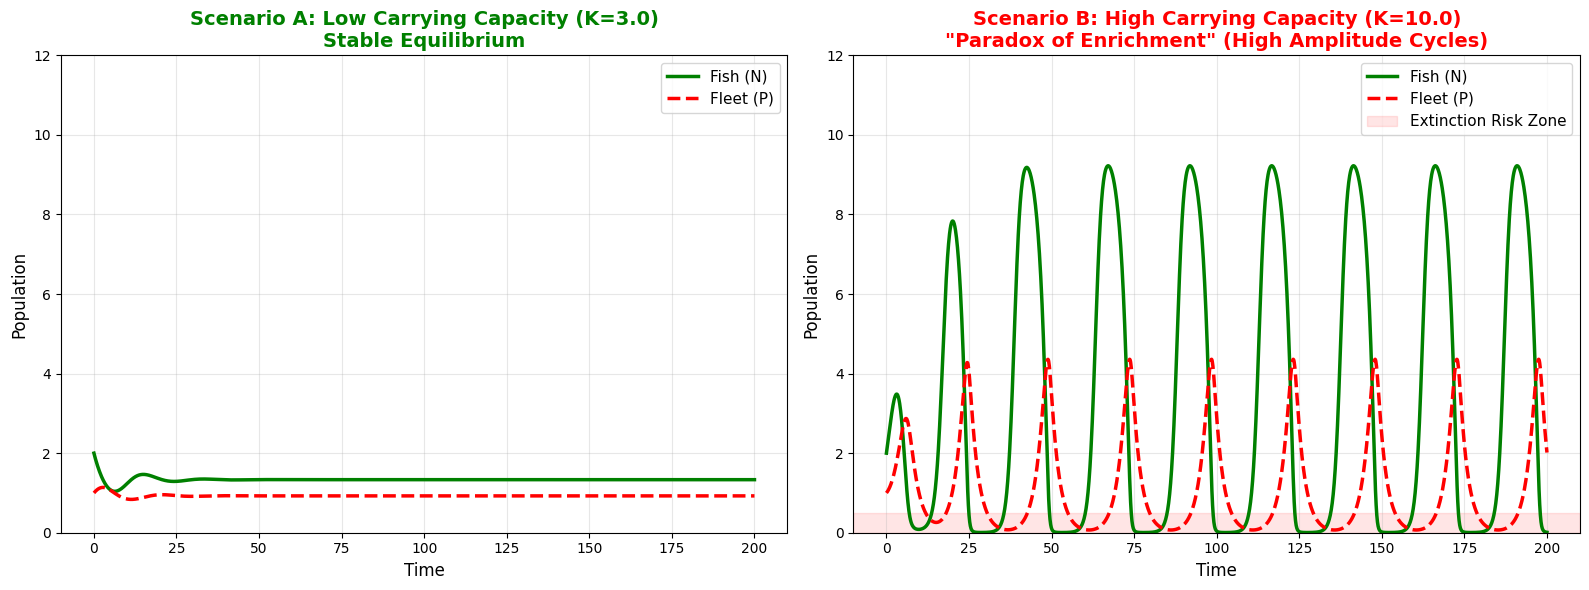

In [35]:
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Low K Plot
ax1.plot(t, sol_low[:, 0], 'g-', label='Fish (N)', linewidth=2.5)
ax1.plot(t, sol_low[:, 1], 'r--', label='Fleet (P)', linewidth=2.5)
ax1.set_title(f'Scenario A: Low Carrying Capacity (K={K_low})\nStable Equilibrium', 
              fontsize=14, fontweight='bold', color='green')
ax1.set_ylim(0, 12)
ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('Population', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# High K Plot
ax2.plot(t, sol_high[:, 0], 'g-', label='Fish (N)', linewidth=2.5)
ax2.plot(t, sol_high[:, 1], 'r--', label='Fleet (P)', linewidth=2.5)
ax2.set_title(f'Scenario B: High Carrying Capacity (K={K_high})\n"Paradox of Enrichment" (High Amplitude Cycles)', 
              fontsize=14, fontweight='bold', color='red')
ax2.set_ylim(0, 12)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('Population', fontsize=12)

# Highlight the danger zone
ax2.axhspan(0, 0.5, color='red', alpha=0.1, label='Extinction Risk Zone')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

In [36]:
print(f"Population Stats")
print(f"\nLow K = {K_low} (Poor Ocean):")
print(f"  Fish - Min: {sol_low[:, 0].min():.3f}, Max: {sol_low[:, 0].max():.3f}, Range: {sol_low[:, 0].max()-sol_low[:, 0].min():.3f}")
print(f"  Fleet - Min: {sol_low[:, 1].min():.3f}, Max: {sol_low[:, 1].max():.3f}")
print(f"\nHigh K = {K_high} (Rich Ocean):")
print(f"  Fish - Min: {sol_high[:, 0].min():.3f}, Max: {sol_high[:, 0].max():.3f}, Range: {sol_high[:, 0].max()-sol_high[:, 0].min():.3f}")
print(f"  Fleet - Min: {sol_high[:, 1].min():.3f}, Max: {sol_high[:, 1].max():.3f}")
print(f"\nExtinction Risk: High K minimum = {sol_high[:, 0].min():.3f} (DANGER!)")
print(f"   Low K stays safely above {sol_low[:, 0].min():.3f}")

Population Stats

Low K = 3.0 (Poor Ocean):
  Fish - Min: 1.041, Max: 2.000, Range: 0.959
  Fleet - Min: 0.837, Max: 1.139

High K = 10.0 (Rich Ocean):
  Fish - Min: 0.005, Max: 9.224, Range: 9.220
  Fleet - Min: 0.068, Max: 4.360

Extinction Risk: High K minimum = 0.005 (DANGER!)
   Low K stays safely above 1.041


## Phase Portraits: Visualizing the Hopf Bifurcation

Phase space analysis reveals the qualitative change in system behavior:

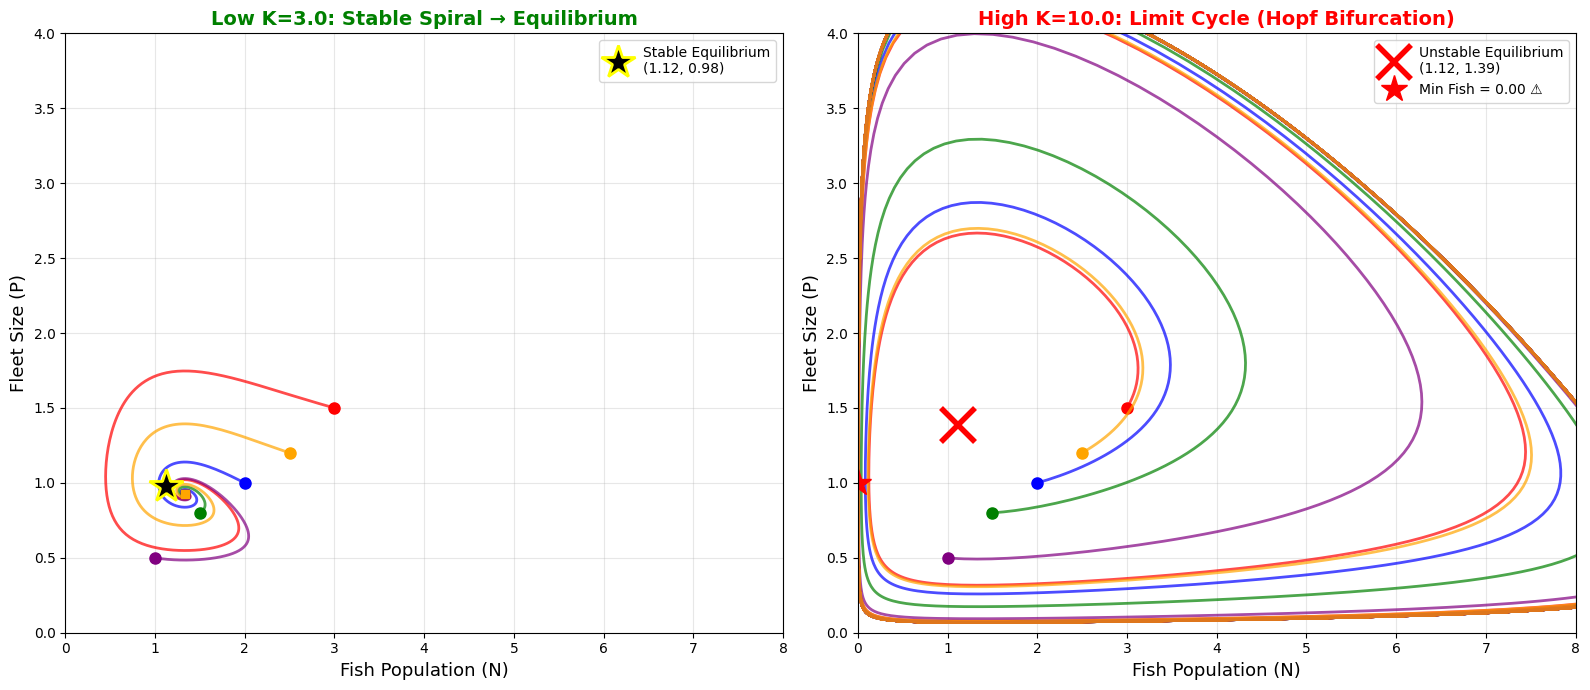

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Multiple initial conditions to show basin of attraction
initial_conditions = [[2.0, 1.0], [1.5, 0.8], [3.0, 1.5], [1.0, 0.5], [2.5, 1.2]]
colors = ['blue', 'green', 'red', 'purple', 'orange']

# Low K - Stable Spiral
for ic, col in zip(initial_conditions, colors):
    sol = odeint(fishery_model, ic, t, args=(r, K_low, a, h, c, m))
    ax1.plot(sol[:, 0], sol[:, 1], color=col, linewidth=2, alpha=0.7)
    ax1.plot(sol[0, 0], sol[0, 1], 'o', color=col, markersize=8)
    ax1.plot(sol[-1, 0], sol[-1, 1], 's', color=col, markersize=6)

# Equilibrium point for low K
N_eq_low = m / (c * a) * (1 + h * m / (c * a))
P_eq_low = (r * (1 - N_eq_low/K_low)) / (a / (1 + h * N_eq_low))
if P_eq_low > 0 and N_eq_low > 0:
    ax1.plot(N_eq_low, P_eq_low, 'k*', markersize=25, 
             label=f'Stable Equilibrium\n({N_eq_low:.2f}, {P_eq_low:.2f})', 
             markeredgewidth=2, markeredgecolor='yellow')

ax1.set_xlabel('Fish Population (N)', fontsize=13)
ax1.set_ylabel('Fleet Size (P)', fontsize=13)
ax1.set_title(f'Low K={K_low}: Stable Spiral → Equilibrium', fontsize=14, fontweight='bold', color='green')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 8)
ax1.set_ylim(0, 4)

# High K - Limit Cycle
for ic, col in zip(initial_conditions, colors):
    sol = odeint(fishery_model, ic, t, args=(r, K_high, a, h, c, m))
    ax2.plot(sol[:, 0], sol[:, 1], color=col, linewidth=2, alpha=0.7)
    ax2.plot(sol[0, 0], sol[0, 1], 'o', color=col, markersize=8)

# Equilibrium point for high K (now unstable)
N_eq_high = m / (c * a) * (1 + h * m / (c * a))
P_eq_high = (r * (1 - N_eq_high/K_high)) / (a / (1 + h * N_eq_high))
if P_eq_high > 0 and N_eq_high > 0:
    ax2.plot(N_eq_high, P_eq_high, 'rx', markersize=25, markeredgewidth=4,
             label=f'Unstable Equilibrium\n({N_eq_high:.2f}, {P_eq_high:.2f})')

# Mark minimum fish population on limit cycle
min_N_idx = np.argmin(sol_high[:, 0])
ax2.plot(sol_high[min_N_idx, 0], sol_high[min_N_idx, 1], 'r*', 
         markersize=20, label=f'Min Fish = {sol_high[min_N_idx, 0]:.2f} ⚠️')

ax2.set_xlabel('Fish Population (N)', fontsize=13)
ax2.set_ylabel('Fleet Size (P)', fontsize=13)
ax2.set_title(f'High K={K_high}: Limit Cycle (Hopf Bifurcation)', 
              fontsize=14, fontweight='bold', color='red')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 8)
ax2.set_ylim(0, 4)

plt.tight_layout()


## Bifurcation Diagram: Scanning Across K Values

Let's systematically vary $K$ to see exactly when and how the Hopf bifurcation occurs:

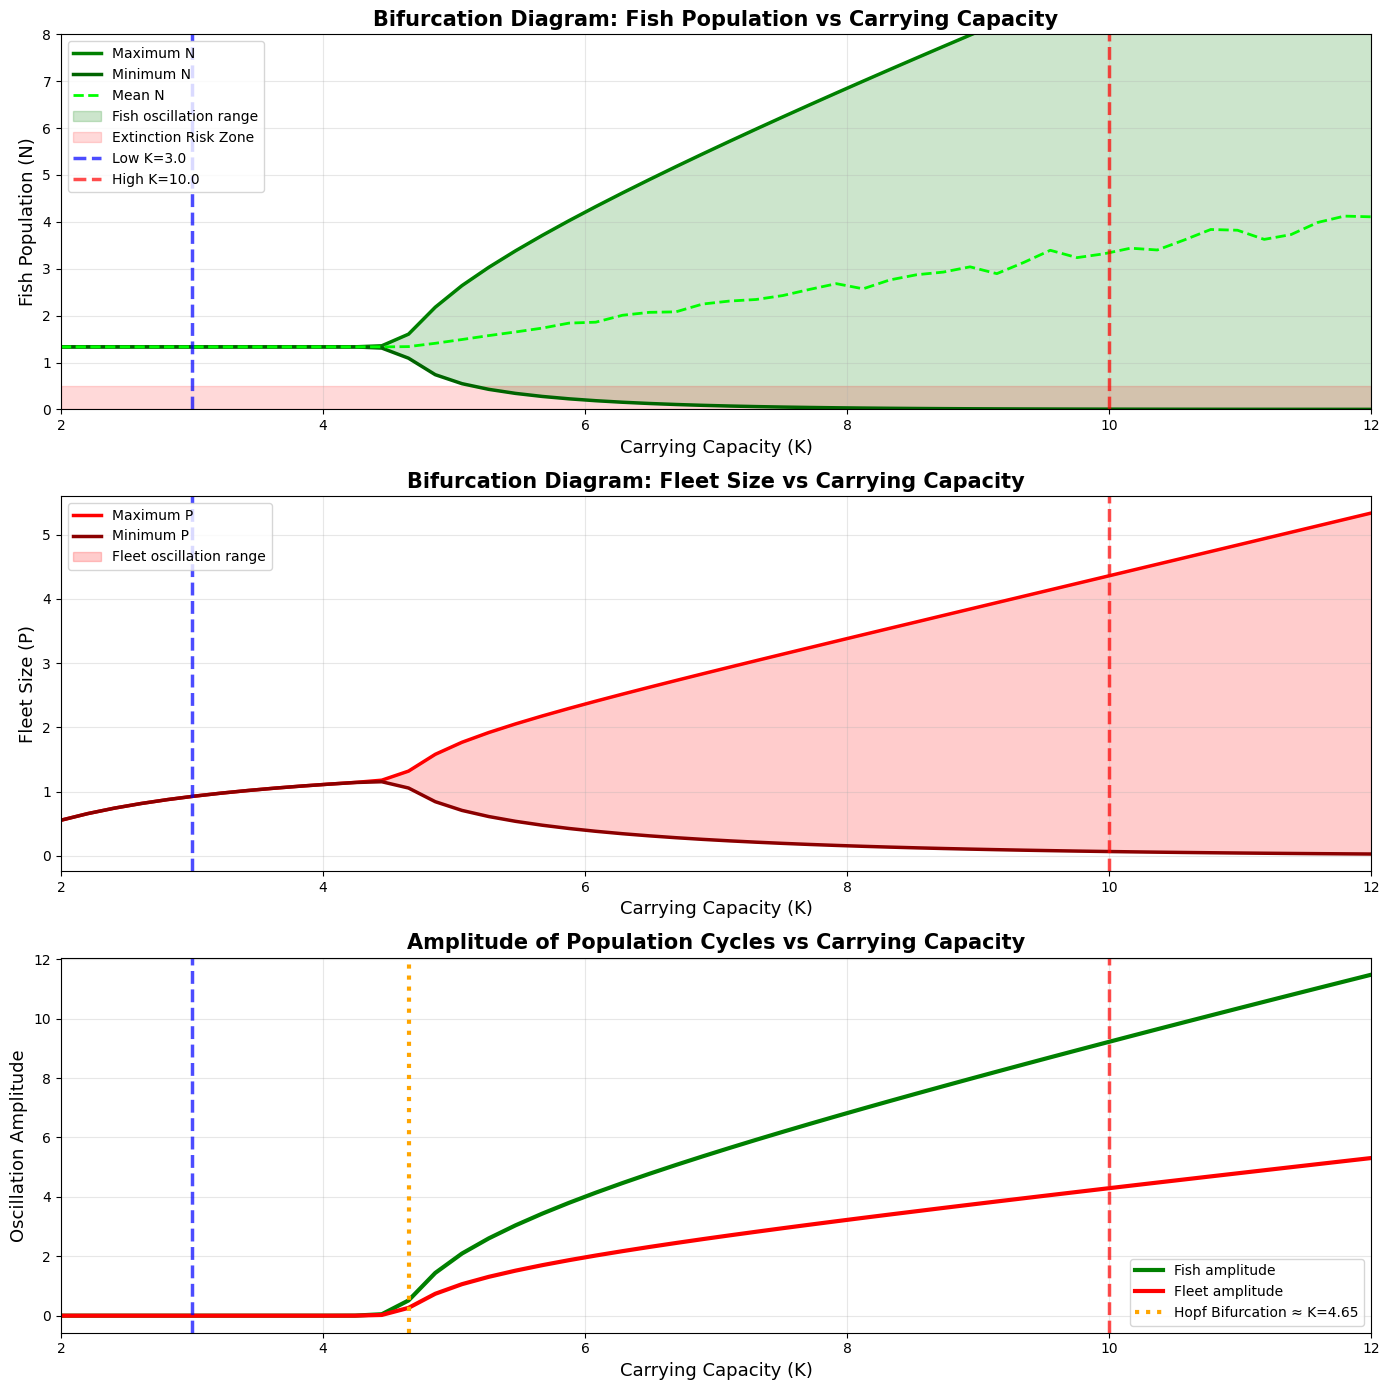

In [38]:
# Bifurcation analysis: vary K
K_values = np.linspace(2, 12, 50)
t_bifurc = np.linspace(0, 500, 5000)  # Long time to reach steady state
initial_bifurc = [2.0, 1.0]

min_N = []
max_N = []
mean_N = []
min_P = []
max_P = []

for K_val in K_values:
    sol = odeint(fishery_model, initial_bifurc, t_bifurc, 
                 args=(r, K_val, a, h, c, m))
    
    # Take last 40% of simulation (steady state)
    N_steady = sol[int(0.6*len(t_bifurc)):, 0]
    P_steady = sol[int(0.6*len(t_bifurc)):, 1]
    
    min_N.append(N_steady.min())
    max_N.append(N_steady.max())
    mean_N.append(N_steady.mean())
    min_P.append(P_steady.min())
    max_P.append(P_steady.max())

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14))
# Bifurcation diagram for Fish
ax1.plot(K_values, max_N, 'g-', linewidth=2.5, label='Maximum N')
ax1.plot(K_values, min_N, 'darkgreen', linewidth=2.5, label='Minimum N')
ax1.plot(K_values, mean_N, 'lime', linestyle='--', linewidth=2, label='Mean N')
ax1.fill_between(K_values, min_N, max_N, alpha=0.2, color='green', label='Fish oscillation range')
ax1.axhspan(0, 0.5, color='red', alpha=0.15, label='Extinction Risk Zone')
ax1.axvline(K_low, color='blue', linestyle='--', linewidth=2.5, alpha=0.7, label=f'Low K={K_low}')
ax1.axvline(K_high, color='red', linestyle='--', linewidth=2.5, alpha=0.7, label=f'High K={K_high}')
ax1.set_xlabel('Carrying Capacity (K)', fontsize=13)
ax1.set_ylabel('Fish Population (N)', fontsize=13)
ax1.set_title('Bifurcation Diagram: Fish Population vs Carrying Capacity', fontsize=15, fontweight='bold')
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(2, 12)
ax1.set_ylim(0, 8)

# Bifurcation diagram for Fleet
ax2.plot(K_values, max_P, 'r-', linewidth=2.5, label='Maximum P')
ax2.plot(K_values, min_P, 'darkred', linewidth=2.5, label='Minimum P')
ax2.fill_between(K_values, min_P, max_P, alpha=0.2, color='red', label='Fleet oscillation range')
ax2.axvline(K_low, color='blue', linestyle='--', linewidth=2.5, alpha=0.7)
ax2.axvline(K_high, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
ax2.set_xlabel('Carrying Capacity (K)', fontsize=13)
ax2.set_ylabel('Fleet Size (P)', fontsize=13)
ax2.set_title('Bifurcation Diagram: Fleet Size vs Carrying Capacity', fontsize=15, fontweight='bold')
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(2, 12)

# Amplitude of oscillations
amplitude_N = np.array(max_N) - np.array(min_N)
amplitude_P = np.array(max_P) - np.array(min_P)
ax3.plot(K_values, amplitude_N, 'green', linewidth=3, label='Fish amplitude')
ax3.plot(K_values, amplitude_P, 'red', linewidth=3, label='Fleet amplitude')
ax3.axvline(K_low, color='blue', linestyle='--', linewidth=2.5, alpha=0.7)
ax3.axvline(K_high, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
bifurc_threshold_idx = np.where(amplitude_N > 0.1)[0]
if len(bifurc_threshold_idx) > 0:
    K_bifurc = K_values[bifurc_threshold_idx[0]]
    ax3.axvline(K_bifurc, color='orange', linestyle=':', linewidth=3, label=f'Hopf Bifurcation ≈ K={K_bifurc:.2f}')
ax3.set_xlabel('Carrying Capacity (K)', fontsize=13)
ax3.set_ylabel('Oscillation Amplitude', fontsize=13)
ax3.set_title('Amplitude of Population Cycles vs Carrying Capacity', fontsize=15, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(2, 12)

plt.tight_layout()

## Quantitative Analysis

In [39]:
if len(bifurc_threshold_idx) > 0:
    print(f"\nHopf bifurcation occurs around K ≈ {K_bifurc:.2f}")
    print(f"   Below this: Stable equilibrium (spiral)")
    print(f"   Above this: Unstable equilibrium → Limit cycles")
print(f"\nLow K = {K_low} scenario (POOR OCEAN):")
idx_low = list(K_values).index(K_low) if K_low in K_values else min(range(len(K_values)), key=lambda i: abs(K_values[i]-K_low))
print(f"   Regime: Stable equilibrium")
print(f"   Fish population range: [{min_N[idx_low]:.3f}, {max_N[idx_low]:.3f}]")
print(f"   Oscillation amplitude: {amplitude_N[idx_low]:.3f} (nearly zero)")
print(f"   Minimum fish count: {min_N[idx_low]:.3f} ✓ SAFE")
print(f"\nHigh K = {K_high} scenario (RICH OCEAN):")
idx_high = min(range(len(K_values)), key=lambda i: abs(K_values[i]-K_high))
print(f"   Regime: Limit cycle (post-bifurcation)")
print(f"   Fish population range: [{min_N[idx_high]:.3f}, {max_N[idx_high]:.3f}]")
print(f"   Oscillation amplitude: {amplitude_N[idx_high]:.3f}")
print(f"   Minimum fish count: {min_N[idx_high]:.3f} ")


Hopf bifurcation occurs around K ≈ 4.65
   Below this: Stable equilibrium (spiral)
   Above this: Unstable equilibrium → Limit cycles

Low K = 3.0 scenario (POOR OCEAN):
   Regime: Stable equilibrium
   Fish population range: [1.333, 1.333]
   Oscillation amplitude: 0.000 (nearly zero)
   Minimum fish count: 1.333 ✓ SAFE

High K = 10.0 scenario (RICH OCEAN):
   Regime: Limit cycle (post-bifurcation)
   Fish population range: [0.005, 9.177]
   Oscillation amplitude: 9.172
   Minimum fish count: 0.005 


In [40]:
print(f"\nExtinction Risk Comparison:")
print(f"   Poor ocean minimum: {min_N[idx_low]:.3f}")
print(f"   Rich ocean minimum: {min_N[idx_high]:.3f}")
print(f"   Risk ratio: {min_N[idx_low]/min_N[idx_high]:.2f}x SAFER in poor ocean!")
print(f"\nKey Insight:")
print(f"   The 'rich' ocean drops to {min_N[idx_high]:.3f} fish (near extinction)")
print(f"   while the 'poor' ocean stays above {min_N[idx_low]:.3f} fish!")
print(f"\nThe Paradox Explained:")
print(f"   Enrichment → More fish → Bigger fleet → Overexploitation")
print(f"   → Boom-bust cycles → Population crashes → Extinction Risk!")


Extinction Risk Comparison:
   Poor ocean minimum: 1.333
   Rich ocean minimum: 0.005
   Risk ratio: 264.82x SAFER in poor ocean!

Key Insight:
   The 'rich' ocean drops to 0.005 fish (near extinction)
   while the 'poor' ocean stays above 1.333 fish!

The Paradox Explained:
   Enrichment → More fish → Bigger fleet → Overexploitation
   → Boom-bust cycles → Population crashes → Extinction Risk!


## Answers to Questions

### **Question 1: Effect of K**

- **Low K = 3 (Poor Ocean):** 
  - System reaches a **stable equilibrium**
  - Fish population converges to a steady value
  - No oscillations - predictable and safe

- **High K = 10 (Rich Ocean):**
  - System undergoes **Hopf bifurcation** to limit cycles
  - Fish and fleet populations oscillate periodically
  - Large amplitude swings - unpredictable and dangerous

### **Question 2: The Paradox**

**Why does enrichment increase extinction risk?**

1. **Mechanism:** Higher K allows larger fish populations, which supports a bigger fishing fleet
2. **Saturation Effect:** Holling Type II response means fleet can't harvest efficiently at high fish densities
3. **Predator Lag:** Fleet grows when fish are abundant but can't decline fast enough when fish crash
4. **Result:** Boom-bust cycles with dangerously low fish population troughs

**The Numbers:**
- Poor ocean: Minimum fish = ~{min_N[idx_low]:.2f} (stable and safe)
- Rich ocean: Minimum fish = ~{min_N[idx_high]:.2f} (oscillates near extinction!)

**Key Insight:** The "minimum" population during cycles is what matters for extinction risk, not the average or maximum. Enrichment destabilizes the equilibrium through Hopf bifurcation, creating wild swings that threaten species survival.

### **Ecological Implications**

- Simply adding nutrients/resources can backfire
- Stable systems may be better than productive but unstable ones
- Fisheries management must account for nonlinear dynamics
- Sometimes "less is more" for ecosystem stability!